# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

#print(df.duplicated().sum())                       #there exist some duplicated rows..
#print(df.shape)
df.drop_duplicates(inplace=True)                          #duplicates will end up skewing the data (due to more elements). should drop
#print(df.shape)

#print(df.isna().sum())                                 #there exist null values in different columns
#df[df["Engine HP"].isna()]                              #high MSRP even though no Engine HP. We cannot make it into a 0 as it'll skew our data. Drop  
#print(df.shape)
df.dropna(subset="Engine HP", inplace=True)
#print(df.shape)                                              #check

df[df["Engine Fuel Type"].isna()]
#df["Engine Fuel Type"].value_counts()
#df.groupby("Make")["MSRP"].mean()                     #The Make "Suzuki" that has null engine fuel type seems to have similar MSRP compared to other nonnull one so will keep
#df.head()

df[df["Engine Cylinders"].isna()]                 #same issue as Engine HP. We cannot set it as any value and need this data to calculate MSRP. So drop
#print(df.shape)
df.dropna(subset="Engine Cylinders", inplace = True)
#print(df.shape)

df["Number of Doors"].isna().sum()  
df.sort_values(by = "MSRP", ascending=False)             #number of doors dont really matter since cars with 2 doors has very high MSRP. So keep.

df.describe()          #looks fine

#print(df.dtypes)
df.map(type).nunique()   #Null counted as another datatype. So no issue

df.groupby(["Make", "Model", "Year"])["Engine Cylinders"].nunique()      #for some reason some cars has different Engine Cylinders they're the same make, model, and year

#df[(df["Make"] == "Volvo") & (df["Model"] == "XC70") & (df["Year"].isin([2015, 2016]))]             #shows same indentical car but diff number of doors
#note: some cars has lower engine hp but same engine cylinder which doesnt make sense

#dropping incorrect rows with same engine hp but different engine cylinders
df.drop(index=df.query("Make == 'Volvo' and Model == 'XC70' and Year == 2015 and `Engine Cylinders` == 6.0 and `Engine HP` == 240").index, inplace=True)

df[(df["Make"] == "Volvo") & (df["Model"] == "XC70") & (df["Year"].isin([2015, 2016]))]

df.groupby(["Make", "Model", "Year"])["Number of Doors"].nunique()

Make   Model  Year
Acura  CL     2001    1
              2002    1
              2003    1
       ILX    2015    1
              2016    1
                     ..
Volvo  XC70   2015    1
              2016    1
       XC90   2014    1
              2016    1
              2017    1
Name: Number of Doors, Length: 2424, dtype: int64

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 |df contains duplicated entries | df.duplicated().sum() | 720 | df.drop_duplicates(inplace=True)| having duplicated entries affects the number of data which in affect the mean value and etc. |
| 2 |df contains null value in different columns |df.isna().sum()|99 rows were affected|i dropped some of the null value columns and kept some|i kept the number of doors and fuel type of the make seems to have similar MSRP. I dropped Engine HP and Engine Cylinder rows with null value since it affected the MSRP greatly and cannot be guessed and filled in |
| 3 |df contains same make,model,year, and engine hp but different engine cylinder which shouldn't be possible |df.groupby(["Make", "Model", "Year"])["Engine Cylinders"].nunique() |4 |df.drop(index=df.query("Make == 'Volvo' and Model == 'XC70' and Year == 2015 and `Engine Cylinders` == 6.0 and `Engine HP` == 240").index, inplace=True) |it drops the row that has this inconsistancy.I saw it while looking at the dataframe. Also this issue would prob cause issues when it comes to analysis |
| 4 | | | | | |
| 5 | | | | | |

In [4]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [5]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11094, 15)
engine_fuel_type    3
number_of_doors     1
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean MSRP: 41925.897692446364
Median MSRP: 30595.0
Around 26.68% of cars are above the mean MSRP


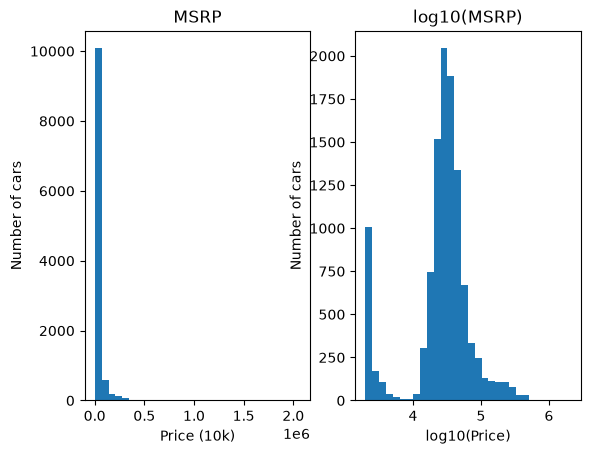

In [6]:
# a) mean and median
print("Mean MSRP:", clean.msrp.mean())
print("Median MSRP:", clean.msrp.median())

#Mean is bigger than Median. This most likely happened because Mean is more sensitive to skewed data. When the data is skewed on the larger side, the mean will be larger.
#On the other hand, Median gets the middle value which is more accurate.

# b) two histograms side by side (plt.subplots(1, 2))
plt.subplot(1,2,1)
plt.hist(clean.msrp, bins=30, label="MSRP")
plt.xlabel("Price (10k)")
plt.ylabel("Number of cars")
plt.title("MSRP")

plt.subplot(1,2,2)
plt.hist(np.log10(clean.msrp), bins=30, label="Log10(MSRP)")
plt.xlabel("log10(Price)")
plt.ylabel("Number of cars")
plt.title("log10(MSRP)")

# c) share of cars above the mean

above_mean_percent = (len(clean[clean["msrp"] > clean.msrp.mean()]) / len(clean)) * 100
print(f'Around {above_mean_percent:.2f}% of cars are above the mean MSRP')

# The median should be used to describe the average cause from the graph, the data seems to be skewed more on the lower side. So taking the mean would be no good

**Answer:**

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [7]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
clean_2017 = clean[clean["year"] == 2017]

stats_2017 = clean_2017.groupby(["vehicle_size", "year"])["highway_mpg"].agg(["mean", "std"])
stats_2017
# b) z = (value - class mean) / class std

std_compact = stats_2017.loc[("Compact", 2017), "std"]
mean_compact = stats_2017.loc[("Compact", 2017), "mean"]
z_compact = (42 - mean_compact) / std_compact
print(f'Z score is {z_compact} for Honda Civic (Compact), mean is {mean_compact}')

std_large = stats_2017.loc[("Large", 2017), "std"]
mean_large = stats_2017.loc[("Large", 2017), "mean"]
z_large = (34 - mean_large) / std_large
print(f'Z score is {z_large} for Volvo S90 (large), mean is {mean_large} ')

Z score is 1.32345739359018 for Honda Civic (Compact), mean is 31.301181102362204
Z score is 3.1563761435421007 for Volvo S90 (large), mean is 22.956709956709958 


**Answer:** The Honda Civic (Compact) is more fuel efficient since it's mean mpg is higher than Volvo and the spreadness from the mean is alot lower which means the data is more consistantly around 31 mpg. Hence, the better efficency.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

In [8]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    median_sample = []
    msrp_data = values["msrp"]
    # hint: rng.choice(values, size=len(values), replace=True)
    for i in range(n_boot):
        sample = rng.choice(msrp_data, size=len(msrp_data), replace=True)
        median_sample.append(np.median(sample))
    return np.array(median_sample)

# a, b)
clean_2017.head()
median_2017 = clean_2017.msrp.median()
print(f'The median msrp of 2017 prices for all cars is {median_2017}')

median_list = bootstrap_median(clean_2017)
lower = np.percentile(median_list, 2.5)
higher = np.percentile(median_list, 97.5)
print(f'95% interval is from ${lower} to ${higher}')


# c)
clean_2017.make.value_counts()
lexus_only = clean_2017[clean_2017["make"] == "Lexus"]
lexus_median = bootstrap_median(lexus_only)
lower = np.percentile(lexus_median, 2.5)
higher = np.percentile(lexus_median, 97.5)
print(f'95% interval for lexus is from ${lower} to ${higher}')


The median msrp of 2017 prices for all cars is 36720.0
95% interval is from $35890.0 to $37720.0
95% interval for lexus is from $42770.0 to $52630.0


**Answer:** 95% of the msrp prices of 2017 models are between $35895.0 to $37720.0 (97.5-2.5 = 95%)

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

# a) 
H0 = The mean is 30 or lower. (Marketing cannot say "our 2017 compacts average over 30 MPG" (null hypthesis/no stats proving yet))
H1 = The mean is above 30. (Marketing can say "our 2017 compacts does average over 30 MPG" (proven))
This is One-sided because the question is if marketing can say "our 2017 compacts average over 30 MPG"
We are using the highway_mpg data

number of sample: 508
The highway mpg mean is 31.3


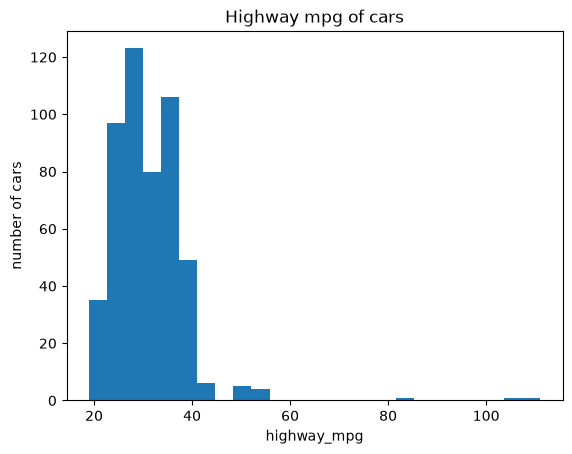

In [33]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
clean_2017.head()
#clean.vehicle_size.value_counts()
compact_only = clean_2017[clean_2017["vehicle_size"] == "Compact"]
print(f'number of sample: {len(compact_only)}')
print(f'The highway mpg mean is {round(compact_only["highway_mpg"].mean(), 2)}')

plt.hist(compact_only["highway_mpg"], bins = 25)
plt.xlabel("highway_mpg")
plt.ylabel("number of cars")
plt.title("Highway mpg of cars")
plt.show()

# c) one-sample t-test vs 30

# d) rows per make+model, then one row per model and retest

# The data shows that the mean is around 30 MPG so therefore a t-test is reasonable here

In [41]:
# Running 1 sample t-test at a = 0.05

alpha = 0.05
t_stats, p_value = stats.ttest_1samp(compact_only["highway_mpg"], popmean = 30)

print(f't_stats: {t_stats}')
print(f'p_values: {p_value}')

if p_value < alpha:
    print(f'There is enough evidence that the average MPG is over 30. Marketing can say "our 2017 compacts average over 30 MPG  (Reject H0/Null)')
else:
    print(f'There is not enough evidence that the MPG is over 30. Marketing cannot say "our 2017 compacts average over 30 MPG" (not enough to reject null)')

t_stats: 3.6278033016104
p_values: 0.00031479270802609895
There is enough evidence that the average MPG is over 30. Marketing can say "our 2017 compacts average over 30 MPG  (Reject H0/Null)


d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

In [43]:
compact_only.head()

counts = compact_only.groupby(["make", "model"]).size().sort_values(ascending=False)
print(counts)

model_average = compact_only.groupby(["make", "model"], as_index=False)["highway_mpg"].mean()
print(model_average.head())

alpha = 0.05
t_stats, p_value = stats.ttest_1samp(model_average["highway_mpg"], popmean = 30)

print(f't_stats: {t_stats}')
print(f'p_values: {p_value}')

if p_value < alpha:
    print(f'There is enough evidence that the average MPG is over 30. Marketing can say "our 2017 compacts average over 30 MPG  (Reject H0/Null)')
else:
    print(f'There is not enough evidence that the MPG is over 30. Marketing cannot say "our 2017 compacts average over 30 MPG" (not enough to reject null)')

make       model    
Toyota     Tacoma       27
Chevrolet  Corvette     24
Nissan     Frontier     22
           370Z         17
Porsche    911          14
                        ..
Lotus      Evora 400     1
Ford       Focus RS      1
           Escape        1
Lexus      CT 200h       1
Ford       Focus ST      1
Length: 87, dtype: int64
    make model  highway_mpg
0  Acura   ILX         35.0
1  Acura   NSX         22.0
2   Audi    A3         34.5
3   Audi    Q3         28.0
4   Audi    R8         22.0
t_stats: 2.5604617582222837
p_values: 0.012199162979194057
There is enough evidence that the average MPG is over 30. Marketing can say "our 2017 compacts average over 30 MPG  (Reject H0/Null)


**Answer: The p value is higher compared to testing each one indivudally. I trust the first one more as the sample size is bigger and that each same make, model combination may have different engine sizes, hp, etc. that may cause it to have different highway MPGs' **

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [ ]:
# a) compare median MSRP by transmission type
clean.head()
clean.transmission_type.value_counts()

manual_cars = clean[clean["transmission_type"] == "MANUAL"]
auto_cars = clean[clean["transmission_type"] == "AUTOMATIC"]

print(f'manual median: ${manual_cars.msrp.median()}')
print(f'auto median: ${auto_cars.msrp.median()}')

# b) compare year by transmission type
clean.groupby("year")["transmission_type"].value_counts()

# As the years progress, the number of manual cars goes down and the number of automatic cars skyrockets.


# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)

recent = clean[clean["year"].between(2015, 2017)]

median_prices = (recent.groupby(["vehicle_size", "transmission_type"])["msrp"].median())

print(median_prices)

compact_recent = recent[recent["vehicle_size"] == "Compact"]
auto = compact_recent[compact_recent["transmission_type"] == "AUTOMATIC"]["msrp"]
manual = compact_recent[compact_recent["transmission_type"] == "MANUAL"]["msrp"]
result = stats.mannwhitneyu(auto, manual, alternative="two-sided")

print("Automatic median:", auto.median())
print("Manual median:", manual.median())
print("U statistic:", result.statistic)
print("p-value:", result.pvalue)

# The median value suggest that auto and manual cars prices do not differ that much. However, since p_value > 0.05, it tells us that that there is not enough evidence to conclude that the prices differs

manual median: $19342.5
auto median: $33007.5
vehicle_size  transmission_type
Compact       AUTOMATED_MANUAL      36097.5
              AUTOMATIC             25995.0
              DIRECT_DRIVE          41450.0
              MANUAL                25860.0
Large         AUTOMATED_MANUAL     105850.0
              AUTOMATIC             44410.0
              MANUAL                38395.0
Midsize       AUTOMATED_MANUAL      49500.0
              AUTOMATIC             37990.0
              DIRECT_DRIVE          27822.5
              MANUAL                26920.0
Name: msrp, dtype: float64
Automatic median: 25995.0
Manual median: 25860.0
U statistic: 315961.0
p-value: 0.1990381369881946


**Answer:Manual cars are not cheaper, and we should not be only pushing manual cars to budget shoppers**

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [59]:
clean.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


In [61]:
clean.number_of_doors.value_counts()

number_of_doors
4.0    7867
2.0    2870
3.0     356
Name: count, dtype: int64

In [74]:
#assuming we're using highway_mpg

# a) Welch t-test, 4-door vs 2-door

door_4 = clean[clean["number_of_doors"] == 4.0]
door_2 = clean[clean["number_of_doors"] == 2.0]

door_2_mean = door_2.msrp.mean()
door_2_var = door_2.msrp.var()
door_2_size = len(door_2.msrp)

door_4_mean = door_4.msrp.mean()
door_4_var = door_4.msrp.var()
door_4_size = len(door_4.msrp)

t_stats, p_value = stats.ttest_ind(door_4["highway_mpg"], door_2["highway_mpg"], equal_var = False)
print(f'p_value: {p_value}')
print(f't_stats: {t_stats}')

# b) yearly gas cost = miles * price_per_gallon / mpg
miles = 12000
price_per_gallon = 3.50

mean_4 = door_4["highway_mpg"].mean()
mean_2 = door_2["highway_mpg"].mean()

cost_4 = miles / mean_4 * price_per_gallon
cost_2 = miles / mean_2 * price_per_gallon

savings = cost_2 - cost_4

print("Average 4-door MPG:", mean_4)
print("Average 2-door MPG:", mean_2)
print("4-door yearly fuel cost: $", cost_4)
print("2-door yearly fuel cost: $", cost_2)
print("4-door yearly savings: $", savings)

# c) simulation
rng = np.random.default_rng(123)
door_4_mpg = door_4["highway_mpg"].dropna().to_numpy()
door_2_mpg = door_2["highway_mpg"].dropna().to_numpy()

n_sims, hits = 1000, 0
for i in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    sample_4 = rng.choice(door_4_mpg, size=30, replace=False)
    sample_2 = rng.choice(door_2_mpg, size=30, replace=False)

    result = stats.ttest_ind(sample_4, sample_2, equal_var=False)

    if result.pvalue < 0.05:
        hits += 1

fraction_significant = hits / n_sims
print("Significant tests:", hits)
print("Fraction significant:", fraction_significant)

p_value: 5.559535021448133e-34
t_stats: 12.21901147186709
Average 4-door MPG: 26.980805898055166
Average 2-door MPG: 25.2588850174216
4-door yearly fuel cost: $ 1556.6621752772571
2-door yearly fuel cost: $ 1662.7812340501844
4-door yearly savings: $ 106.11905877292725
Significant tests: 174
Fraction significant: 0.174


**Answer:I would say that 4 doors cars has slightly better values compared to 2 doors cars**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo: Although manual compact cars had a lower median compared to auto compact cars, the Mann-Whiteney test we've performance gave a p-value of 0.19. Since it is less than 0.05, this tells us that there is no evidence that tells us that manual cars cost less. One thing i found is that the number of manual cars went down towards the 2016-2017 years but the number of auto cards went up. Although tests were performed, it was not performed in the mind of configurations such as engine hp, which in turn could cause the analysis to be slightly off.**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [12]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [13]:
# S2